# Terrain — DEMs as 3-D relief

`Scene3D.terrain` reads a raster through pyramids and warps it by elevation into a `StructuredGrid`, turning a DEM into a true 3-D surface coloured by height.

**Units.** A *geographic* DEM carries lon/lat in **degrees** but elevation in **metres** — left as-is the surface would be a ~100 000:1 vertical needle. `terrain` detects a geographic CRS (through pyramids) and rescales the vertical so `z_exaggeration=1.0` is true-scale and *visible*; a *projected* DEM (metres) is used unchanged. The colour bar always shows real elevation.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

from pyramids.dataset import Dataset
from digitalearth.sources import get_source
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'LisbonElevation.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'

def show(scene, title=''):
    """Screenshot a scene off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]          # exclude the bottom colour-bar strip
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} of the scene differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


## A geographic DEM (Lisbon, EPSG:4326)

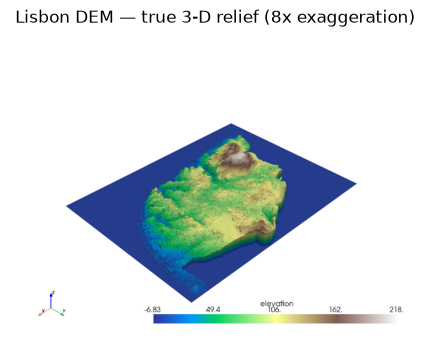

In [2]:
dem = Dataset.read_file(str(DATA / 'LisbonElevation.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, cmap='terrain')
scene.plotter.add_axes()
show(scene, 'Lisbon DEM — true 3-D relief (8x exaggeration)')
scene.close()

## `z_exaggeration` — accentuating relief

Higher exaggeration makes subtle terrain readable; `1.0` is geometrically faithful.

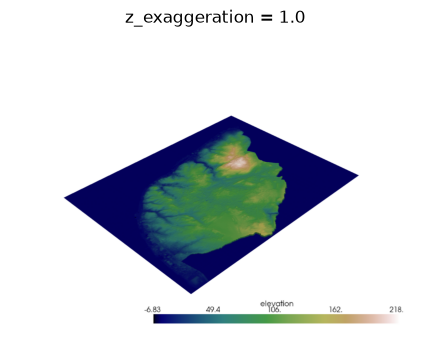

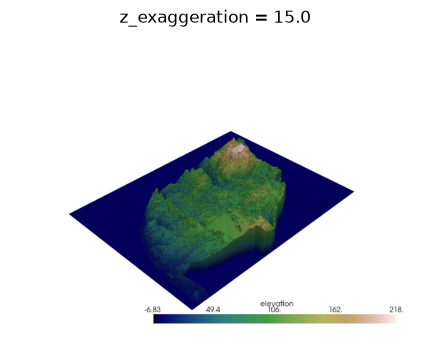

In [3]:
for zexag in (1.0, 15.0):
    scene = Scene3D(off_screen=True)
    scene.terrain(dem, z_exaggeration=zexag, cmap='gist_earth')
    show(scene, f'z_exaggeration = {zexag}')
    scene.close()

## A projected DEM (EPSG:32618, metres)

When x/y are already metres, elevation needs no rescaling — `terrain` uses the values as-is.

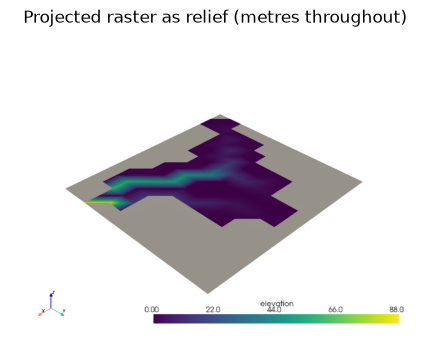

In [4]:
acc = Dataset.read_file(str(DATA / 'acc4000.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(acc, z_exaggeration=1.0, cmap='viridis')
scene.plotter.add_axes()
show(scene, 'Projected raster as relief (metres throughout)')
scene.close()

## Styling pass-through

Extra keywords flow straight to `add_mesh`: `show_edges`, `opacity`, `scalars=None` for a flat colour, lighting (`pbr`), and so on.

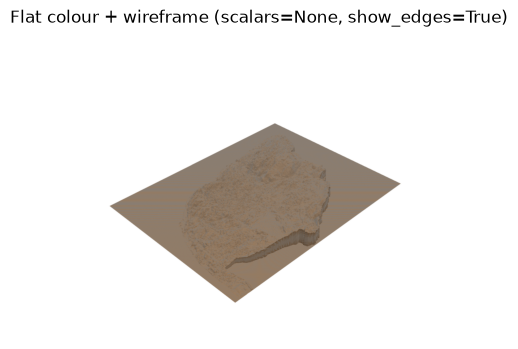

In [5]:
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=8.0, scalars=None, color='peru', show_edges=True, edge_color='gray')
show(scene, 'Flat colour + wireframe (scalars=None, show_edges=True)')
scene.close()